In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import mglearn 
import tensorflow as tf

In [2]:
from sklearn.datasets import fetch_lfw_people 
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler

In [3]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense 

In [4]:
np.random.seed(180) 
tf.random.set_seed(180) 

In [2]:
from sklearn.datasets import fetch_lfw_people

In [3]:
people = fetch_lfw_people( 
min_faces_per_person=20, 
resize=0.7 
) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape

(2341, 5655)
(2341,)


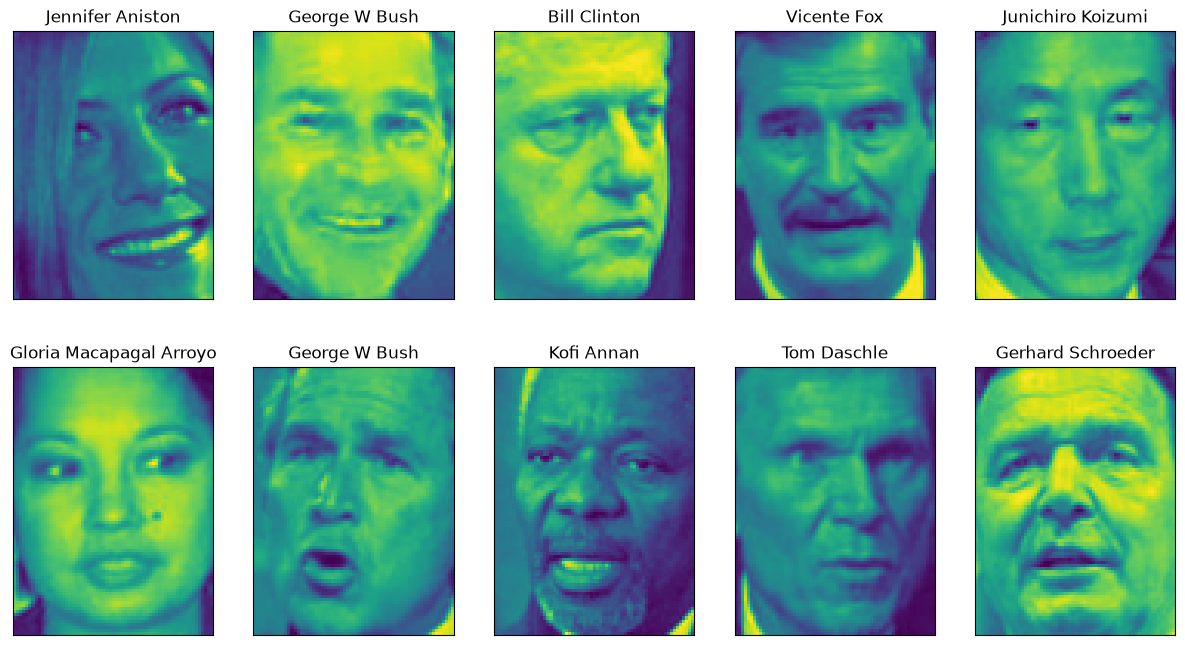

In [9]:
fig, axes = plt.subplots( 
2, 
5, 
figsize=(15,8), 
subplot_kw={'xticks':(), 'yticks':()} 
) 
for target, image, ax in zip( 
people.target,
 people.images, 
        axes.ravel()): 
 ax.imshow(image) 
 
 ax.set_title( 
        people.target_names[target] 
    ) 
 
plt.show() 

In [8]:
import matplotlib.pyplot as plt

In [12]:
X_train, X_test, y_train, y_test = train_test_split( 
    people.data, 
    people.target, 
    test_size=0.2, 
    random_state=20 
) 
 
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
 
batch_size = len(X_train) 
 
print( 
    X_train.shape, 
    y_train.shape, 
    y_test.shape 
) 
 
print( 
    "people.images.shape: {}".format( 
        people.images.shape 
    ) 
) 
 
print( 
    "Number of classes: {}".format( 
        len(people.target_names) 
    ) 
) 

(1872, 5655) (1872,) (469,)
people.images.shape: (2341, 87, 65)
Number of classes: 39


In [11]:
from sklearn.model_selection import train_test_split

In [17]:
counts = np.bincount(people.target) 
 
for i, (count, name) in enumerate( 
        zip(counts, people.target_names)): 
 
    print( 
        "{0:25} {1:3}".format(name,count), 
        end=" " 
    ) 
 
    if (i+1)%3 == 0: 
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Ariel Sharon               77 Atal Bihari Vajpayee       24 
Bill Clinton               29 Colin Powell              236 Donald Rumsfeld           121 
George Robertson           22 George W Bush             530 Gerhard Schroeder         109 
Gloria Macapagal Arroyo    44 Hamid Karzai               22 Hans Blix                  39 
Igor Ivanov                20 Jack Straw                 28 Jacques Chirac             52 
Jean Chretien              55 Jennifer Aniston           21 Jennifer Capriati          42 
John Ashcroft              53 Juan Carlos Ferrero        28 Junichiro Koizumi          60 
Kofi Annan                 32 Laura Bush                 41 Lindsay Davenport          22 
Lleyton Hewitt             41 Megawati Sukarnoputri      33 Pete Sampras               22 
Rudolph Giuliani           26 Saddam Hussein             23 Serena Williams            52 

In [16]:
import numpy as np

In [18]:
mask = np.zeros( 
    people.target.shape, 
    dtype=np.bool_ 
) 
 
for target in np.unique(people.target): 
 
    mask[ 
        np.where(people.target == target)[0][:50] 
    ] = True 
X_people = people.data[mask] 
 
y_people = people.target[mask] 
# Scale pixel values 
X_people = X_people / 255.0

In [24]:
X_train, X_test, y_train, y_test = train_test_split( 
    X_people, 
    y_people, 
    stratify=y_people, 
    random_state=0 
) 
# KNN without PCA 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train, 
    y_train 
) 
print( 
    "Test set score of 1-nn: {:.2f}".format( 
        knn.score( 
            X_test, 
            y_test 
        ) 
    ) 
) 

Test set score of 1-nn: 0.39


In [23]:
from sklearn.neighbors import KNeighborsClassifier

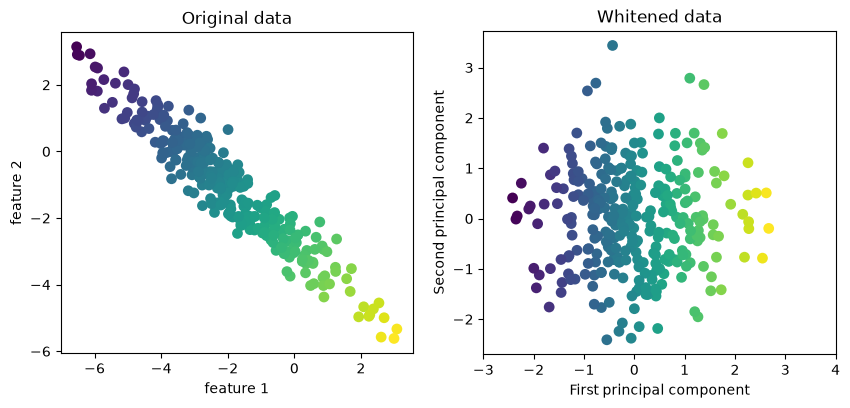

In [28]:
mglearn.plots.plot_pca_whitening() 
plt.show() 

In [27]:
import mglearn
import matplotlib.pyplot as plt

In [33]:
pca = PCA( 
    n_components=100, 
    whiten=True, 
    random_state=0 
).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test) 
print( 
    "X_train_pca.shape: {}".format( 
        X_train_pca.shape 
    ) 
) 
# KNN with PCA 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train_pca, 
    y_train 
) 
 
print( 
    "Test set accuracy: {:.2f}".format( 
        knn.score( 
            X_test_pca, 
            y_test 
        ) 
    ) 
) 
print( 
"pca.components_.shape: {}".format( 
pca.components_.shape )) 

X_train_pca.shape: (1755, 100)
Test set accuracy: 0.48
pca.components_.shape: (100, 5655)


In [32]:
from sklearn.decomposition import PCA


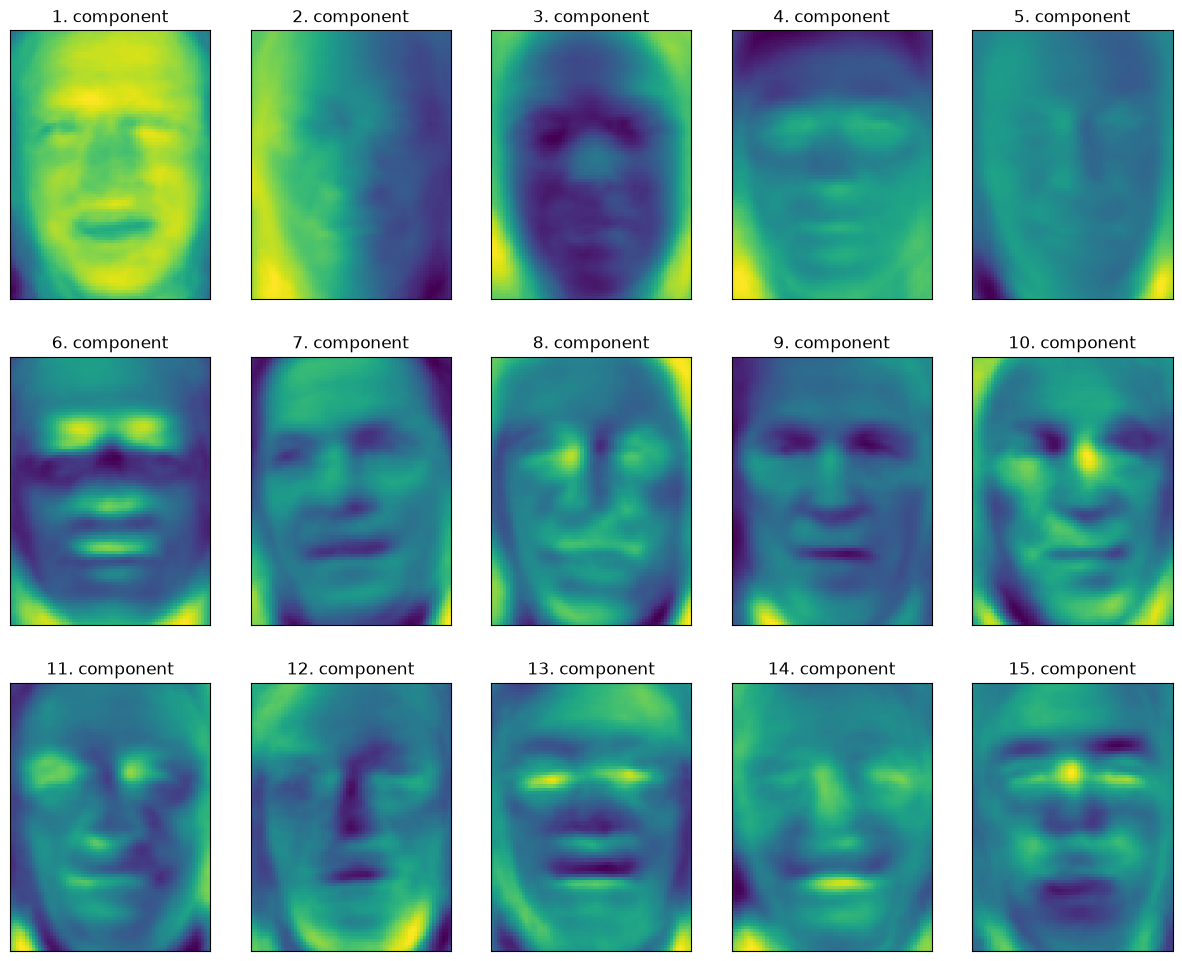

In [35]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(
    zip(pca.components_, axes.ravel())
):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title(
        "{}. component".format(i + 1)
    )

plt.show()

In [39]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( 
    X_train_pca 
) 
X_test_scaled = scaler.transform( 
    X_test_pca 
)

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [42]:
model = Sequential([ 
 
    Input( 
        shape=(100,) 
    ), 
 
    Dense( 
        300, 
        activation='relu' 
    ), 
 
    Dense( 
        100, 
        activation='relu' 
    ), 
 
    Dense( 
        len(np.unique(y_train)), 
        activation='softmax' 
    ) 
 
])

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [43]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [44]:
history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=50,
    epochs=20,
    shuffle=False,
    verbose=1
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2165 - loss: 3.2856
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2262 - loss: 3.1484
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2262 - loss: 3.1205
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2262 - loss: 3.0876
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2274 - loss: 3.0428
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2336 - loss: 2.9867
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2519 - loss: 2.9185
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2701 - loss: 2.8403
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2923 - loss: 2.7539
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3174 - loss: 2.6734
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3396 - loss: 2.5949
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3630 - lo

In [45]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1) 
print("Test Loss:", loss) 
print("Test Accuracy:", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4539 - loss: 2.1025
Test Loss: 2.1025211811065674
Test Accuracy: 0.45392492413520813
